# Hydranet - 8-valued treat

In [1]:
import sklearn
import numpy as np
import keras
import pandas
import tensorflow as tf
import glob
import os
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras.backend as K
from keras.engine.topology import Layer
from keras.metrics import binary_accuracy, categorical_accuracy
from keras.layers import Input, Dense, Concatenate, BatchNormalization, Dropout, Softmax
from keras.models import Model
from keras import regularizers
from keras.optimizers import RMSprop, SGD, Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.compat.v1.keras.utils import to_categorical

import matplotlib.pyplot as plt


random.seed(1)
tf.compat.v1.set_random_seed(1)
np.random.seed(1)


In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:XLA_CPU:0', device_type='XLA_CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:XLA_GPU:0', device_type='XLA_GPU')]

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


## Load Data

In [4]:
def load_and_format_covariates_ihdp(file_path='/home/bvelasco/PhD/Dragonnet/dragonnet/dat/ihdp/eight_case/'):

    data = pandas.read_csv(file_path, delimiter=',')

    binfeats = ["bw","b.head","preterm","birth.o","nnhealth","momage"]
    contfeats = ["sex","twin","b.marr","mom.lths","mom.hs",	"mom.scoll","cig","first","booze","drugs","work.dur","prenatal","ark","ein","har","mia","pen","tex","was",'momwhite','momblack','momhisp']
    
    mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7 = data['mu_0'], data['mu_1'], data['mu_2'], data['mu_3'], data['mu_4'], data['mu_5'], data['mu_6'], data['mu_7'] 
    perm = binfeats + contfeats
    x = data[perm]
    return x

In [5]:
def load_all_other_crap(file_path='/home/bvelasco/PhD/Dragonnet/dragonnet/dat/ihdp/eight_case/'):
    data = pandas.read_csv(file_path, delimiter=',')
    t, y, y0, y1, y2, y3, y4, y5, y6, y7 = data['z'], data['y'], data['y_0'], data['y_1'],  data['y_2'], data['y_3'], data['y_4'], data['y_5'], data['y_6'], data['y_7']
    mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7 =  data['mu_0'], data['mu_1'], data['mu_2'], data['mu_3'], data['mu_4'], data['mu_5'], data['mu_6'], data['mu_7']
    return t.values.reshape(-1, 1), y, y0, y1, y2, y3, y4, y5, y6, y7, mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7



## Losses

In [6]:
def regression_loss(concat_true, concat_pred):
    y_true = concat_true[:, 0]
    t_true = concat_true[:, 1]

    y0_pred = concat_pred[:, 0]
    y1_pred = concat_pred[:, 1]
    y2_pred = concat_pred[:, 2]
    y3_pred = concat_pred[:, 3]
    y4_pred = concat_pred[:, 4]
    y5_pred = concat_pred[:, 5]
    y6_pred = concat_pred[:, 6]
    y7_pred = concat_pred[:, 7]
    
    loss0 = tf.reduce_sum(tf.cast(t_true==0, tf.float32) * tf.square(y_true - y0_pred))
    loss1 = tf.reduce_sum(tf.cast(t_true==1, tf.float32) * tf.square(y_true - y1_pred))
    loss2 = tf.reduce_sum(tf.cast(t_true==2, tf.float32) * tf.square(y_true - y2_pred))
    loss3 = tf.reduce_sum(tf.cast(t_true==3, tf.float32) * tf.square(y_true - y3_pred))
    loss4 = tf.reduce_sum(tf.cast(t_true==4, tf.float32) * tf.square(y_true - y4_pred))
    loss5 = tf.reduce_sum(tf.cast(t_true==5, tf.float32) * tf.square(y_true - y5_pred))
    loss6 = tf.reduce_sum(tf.cast(t_true==6, tf.float32) * tf.square(y_true - y6_pred))
    loss7 = tf.reduce_sum(tf.cast(t_true==7, tf.float32) * tf.square(y_true - y7_pred))


    return loss0 + loss1 + loss2 + loss3 + loss4 + loss5 + loss6 + loss7 


def categorical_classification_loss(concat_true, concat_pred):
    t_true = concat_true[:, 1]
    t_pred = concat_pred[:, 8:16]
    t_pred = (t_pred + 0.001) / 1.002
    
    #temp = to_categorical(t_true, num_classes=3)
    #temp = to_categorical(t_true, num_classes=3, dtype='int')
    temp = tf.one_hot(tf.cast(t_true, tf.int32), 8)
    temp = tf.cast(temp, tf.float32)
    
    temp1 = tf.convert_to_tensor(temp)
    temp2 = K.categorical_crossentropy(temp1, t_pred)
    losst = tf.reduce_sum(temp2)

    return losst


def dragonnet_loss_cross(concat_true, concat_pred):
    return regression_loss(concat_true, concat_pred) + categorical_classification_loss(concat_true, concat_pred)



def treatment_accuracy(concat_true, concat_pred): # For training monitoring purposes
    t_true = concat_true[:, 1]
    t_pred = concat_pred[:, 8:16]
    
    temp = tf.one_hot(tf.cast(t_true, tf.int32), 8)
    temp = tf.cast(temp, tf.float32)

    return categorical_accuracy(temp, t_pred) # .numpy()


def track_epsilon(concat_true, concat_pred): # For training monitoring purposes
    epsilons = concat_pred[:, 16:23]
    return tf.abs(tf.reduce_mean(epsilons))


def make_tarreg_loss(ratio=1., dragonnet_loss=dragonnet_loss_cross): # Targeted regularization loss # NOT ADAPTED FOR 5 CASE!!
    def tarreg_ATE_unbounded_domain_loss(concat_true, concat_pred):
        vanilla_loss = dragonnet_loss(concat_true, concat_pred)

        y_true = concat_true[:, 0]
        t_true = concat_true[:, 1]

        y0_pred = concat_pred[:, 0]
        y1_pred = concat_pred[:, 1]
        y2_pred = concat_pred[:, 2]
        y3_pred = concat_pred[:, 3]
        y4_pred = concat_pred[:, 4]
        y5_pred = concat_pred[:, 5]
        y6_pred = concat_pred[:, 6]
        y7_pred = concat_pred[:, 7]
        t_pred = concat_pred[:, 8:16]
        
        epsilons = concat_pred[:, 16:23]
        t_pred = (t_pred + 0.01) / 1.02
        # t_pred = tf.clip_by_value(t_pred,0.01, 0.99,name='t_pred')
        
        # 8-fold 
        y_pred = tf.cast(t_true==0, tf.float32) * y0_pred + tf.cast(t_true==1, tf.float32) * y1_pred + tf.cast(t_true==2, tf.float32) * y2_pred  +  tf.cast(t_true==3, tf.float32) * y3_pred \
                + tf.cast(t_true==4, tf.float32) * y4_pred + tf.cast(t_true==5, tf.float32) * y5_pred + tf.cast(t_true==6, tf.float32) * y6_pred + tf.cast(t_true==7, tf.float32) * y7_pred
        
        t_pred_current = tf.cast(t_true==0, tf.float32) * t_pred[:,0] + tf.cast(t_true==1, tf.float32) * t_pred[:,1] + tf.cast(t_true==2, tf.float32) * t_pred[:,2]  + tf.cast(t_true==3, tf.float32) * t_pred[:,3] \
                    + tf.cast(t_true==4, tf.float32) * t_pred[:,4] + tf.cast(t_true==5, tf.float32) * t_pred[:,5] + tf.cast(t_true==6, tf.float32) * t_pred[:,6] + tf.cast(t_true==7, tf.float32) * t_pred[:,7] 
        
        # wrong_h =  1 # WARNING: Model misspecification activated
        h = tf.transpose([tf.cast(t_true==1, tf.float32)/t_pred[:,1] - tf.cast(t_true==0, tf.float32)/t_pred[:,0], 
                          tf.cast(t_true==2, tf.float32)/t_pred[:,2] - tf.cast(t_true==0, tf.float32)/t_pred[:,0],
                          tf.cast(t_true==3, tf.float32)/t_pred[:,3] - tf.cast(t_true==0, tf.float32)/t_pred[:,0],
                          tf.cast(t_true==4, tf.float32)/t_pred[:,4] - tf.cast(t_true==0, tf.float32)/t_pred[:,0],
                          tf.cast(t_true==5, tf.float32)/t_pred[:,5] - tf.cast(t_true==0, tf.float32)/t_pred[:,0],
                          tf.cast(t_true==6, tf.float32)/t_pred[:,6] - tf.cast(t_true==0, tf.float32)/t_pred[:,0],
                          tf.cast(t_true==7, tf.float32)/t_pred[:,7] - tf.cast(t_true==0, tf.float32)/t_pred[:,0]])
        
        
        y_pert = y_pred + tf.math.reduce_sum(tf.math.multiply(epsilons,h), axis=1)
        
        targeted_regularization = tf.reduce_sum(tf.square(y_true - y_pert))
        
        
        # Final
        loss = vanilla_loss + ratio * targeted_regularization
        return loss

    return tarreg_ATE_unbounded_domain_loss

## Neural net

In [7]:
# Define epsilon layer
class EpsilonLayer(Layer):

    def __init__(self):
        super(EpsilonLayer, self).__init__()

    def build(self, input_shape):
        # Create a trainable weight variable for this layer.
        self.epsilon = self.add_weight(name='epsilon',
                                       shape=[1, 7],
                                       initializer='RandomNormal',
                                       #  initializer='ones',
                                       trainable=True)
        super(EpsilonLayer, self).build(input_shape)  # Be sure to call this at the end

    def call(self, inputs, **kwargs):
        # import ipdb; ipdb.set_trace()
        return self.epsilon * tf.ones_like(inputs)[:, 0:7]

In [8]:
# Define Hydranet architecture
def make_dragonnet(input_dim, reg_l2, print_model_flag=True):
    """
    Neural net predictive model. The dragon has many heads.
    :param input_dim:
    :param reg:
    :return:
    """
    t_l1 = 0.
    t_l2 = reg_l2
    inputs = Input(shape=(input_dim,), name='input')

    # representation
    x = Dense(units=200, activation='elu', kernel_initializer='RandomNormal')(inputs)
    x = Dense(units=200, activation='elu', kernel_initializer='RandomNormal')(x)

    # G propensity score (R5 vector)
    t_predictions = Dense(units=8, activation = 'softmax')(x) # correct is: softmax

    # HYPOTHESIS
    y0_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)
    y1_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)
    y2_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)
    y3_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)
    y4_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)
    y5_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)
    y6_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)
    y7_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(x)

    # second layer
    y0_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y0_hidden)
    y1_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y1_hidden)
    y2_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y2_hidden)
    y3_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y3_hidden)
    y4_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y4_hidden)
    y5_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y5_hidden)
    y6_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y6_hidden)
    y7_hidden = Dense(units=100, activation='elu', kernel_regularizer=regularizers.l2(reg_l2))(y7_hidden)


    # third layer
    y0_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y0_predictions')(y0_hidden)
    y1_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y1_predictions')(y1_hidden)
    y2_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y2_predictions')(y2_hidden)
    y3_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y3_predictions')(y3_hidden)
    y4_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y4_predictions')(y4_hidden)
    y5_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y5_predictions')(y5_hidden)
    y6_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y6_predictions')(y6_hidden)
    y7_predictions = Dense(units=1, activation=None, kernel_regularizer=regularizers.l2(reg_l2), name='y7_predictions')(y7_hidden)


    # epsilons
    dl = EpsilonLayer()
    epsilons = dl(t_predictions, name='epsilon')
    
    # WARNING! Model misspecification activated
    #garb = inputs*tf.random.uniform([1,])
    #garbage_t = Dense(units=5, activation = 'softmax')(garb)
    
    #concat_pred = Concatenate(1)([y0_predictions, y1_predictions, y2_predictions, garbage_t, epsilons])
    concat_pred = Concatenate(1)([y0_predictions, y1_predictions, y2_predictions, y3_predictions, y4_predictions, y5_predictions, y6_predictions, y7_predictions, t_predictions, epsilons])
    model = Model(inputs=inputs, outputs=concat_pred)
    
    if print_model_flag:
        keras.utils.plot_model(model, 'hydranet_8.png', show_shapes=True)

    return model

### Train function

In [9]:
# Auxiliary function
def _split_output(yt_hat, t, y, y_scaler, x, index):
    q_t0 = y_scaler.inverse_transform(yt_hat[:, 0].copy())
    q_t1 = y_scaler.inverse_transform(yt_hat[:, 1].copy())
    q_t2 = y_scaler.inverse_transform(yt_hat[:, 2].copy())
    q_t3 = y_scaler.inverse_transform(yt_hat[:, 3].copy())
    q_t4 = y_scaler.inverse_transform(yt_hat[:, 4].copy())
    q_t5 = y_scaler.inverse_transform(yt_hat[:, 5].copy())
    q_t6 = y_scaler.inverse_transform(yt_hat[:, 6].copy())
    q_t7 = y_scaler.inverse_transform(yt_hat[:, 7].copy())
    g0 = yt_hat[:, 8].copy()
    g1 = yt_hat[:, 9].copy()
    g2 = yt_hat[:, 10].copy()
    g3 = yt_hat[:, 11].copy()
    g4 = yt_hat[:, 12].copy()
    g5 = yt_hat[:, 13].copy()
    g6 = yt_hat[:, 14].copy()
    g7 = yt_hat[:, 15].copy()
    g = Concatenate(0)([tf.transpose(g0), tf.transpose(g1), tf.transpose(g2), tf.transpose(g3), tf.transpose(g4), tf.transpose(g5), tf.transpose(g6), tf.transpose(g7)])

    if yt_hat.shape[1] == 23:
        eps = yt_hat[:, 16:23]
    else:
        eps = np.zeros_like(yt_hat[:, 2]) #??

    y = y_scaler.inverse_transform(y.copy())
    
    var = "average propensity for t=0: {}, t=1: {}, t=2: {}, t=3: {}, t=4: {}".format(g0.mean(), g1.mean(), g2.mean(), g3.mean(), g4.mean(), g5.mean(), g6.mean(), g7.mean())
    
    print(var)

    return {'q_t0': q_t0, 'q_t1': q_t1, 'q_t2': q_t2, 'q_t3': q_t3, 'q_t4': q_t4, 'q_t5': q_t5, 'q_t6': q_t6, 'q_t7': q_t7, 'g': g, 't': t, 'y': y, 'x': x, 'index': index, 'eps': eps}

In [10]:
def train_and_predict_dragons(t, y_unscaled, x, targeted_regularization=False, output_dir='',
                              knob_loss=dragonnet_loss_cross, ratio=1., dragon='', val_split=0.2, batch_size=64, verbose=0, print_model_flag=True):

    y_unscaled = y_unscaled.values.reshape(-1, 1)
    y_scaler = StandardScaler().fit(y_unscaled)
    y = y_scaler.transform(y_unscaled)
    train_outputs = []
    test_outputs = []

    if dragon == 'tarnet':
        dragonnet = make_tarnet(x.shape[1], 0.01)

    elif dragon == 'dragonnet':
        print("I am here making dragonnet")
        dragonnet = make_dragonnet(x.shape[1], 0.01, print_model_flag=print_model_flag)

    metrics = [regression_loss, categorical_classification_loss, treatment_accuracy, track_epsilon]

    if targeted_regularization:
        loss = make_tarreg_loss(ratio=ratio, dragonnet_loss=knob_loss)
    else:
        loss = knob_loss

    train_index, test_index = train_test_split(np.arange(x.shape[0]), test_size=0.2, random_state=1, shuffle=False)
    #random.shuffle(train_index)
    random.shuffle(test_index)
    
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    t_train, t_test = t[train_index], t[test_index]

    yt_train = np.concatenate([y_train, t_train], 1)

    import time;
    start_time = time.time()

    # With Adam
    dragonnet.compile(
        optimizer=Adam(lr=1e-3),
        loss=loss, metrics=metrics, run_eagerly=False)

    adam_callbacks = [
        TerminateOnNaN(),
        EarlyStopping(monitor='val_loss', patience=2, min_delta=0.),
        ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, verbose=verbose, mode='auto',
                          min_delta=1e-8, cooldown=0, min_lr=0)
    ]
    
    dragonnet.fit(x_train, yt_train, callbacks=adam_callbacks,
                  validation_split=val_split,
                  epochs=100,
                  batch_size=batch_size, verbose=verbose)
    
    # with SGD
    sgd_lr = 1e-6
    momentum = 0.9
    dragonnet.compile(optimizer=SGD(lr=sgd_lr, momentum=momentum, nesterov=True), 
                      loss=loss, metrics=metrics, run_eagerly=False)
    
    sgd_callbacks = [
        TerminateOnNaN(),
        EarlyStopping(monitor='val_loss', patience=40, min_delta=0.),
        ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, verbose=verbose, mode='auto',
                          min_delta=0., cooldown=0, min_lr=0)
    ]
    
    dragonnet.fit(x_train, yt_train, callbacks=sgd_callbacks,
                  validation_split=val_split,
                  epochs=300,
                  batch_size=batch_size, verbose=verbose)
    
    elapsed_time = time.time() - start_time

    # Plot metrics to monitor the training process
    plt.figure()
    plt.plot(dragonnet.history.history['loss'])
    plt.plot(dragonnet.history.history['val_loss'])
    plt.legend(["Train", "Test"])
    plt.title("Loss")
    plt.show() # Training and validation losses
    
    #plt.figure()
    #plt.plot(dragonnet.history.history['treatment_accuracy'])
    #plt.plot(dragonnet.history.history['val_treatment_accuracy'])
    #plt.legend(["Train", "Test"])
    #plt.title("Treatment prediction accuracy")
    #plt.show() # Treatment prediction accuracy
    
    plt.figure()
    plt.plot(dragonnet.history.history['track_epsilon'])
    plt.plot(dragonnet.history.history['val_track_epsilon'])
    plt.legend(["Train", "Test"])
    plt.title("Epsilon value (Regularization term)")
    plt.show() # Epsilon
    
    print("elapsed_time: ", elapsed_time)
    
    yt_hat_test = dragonnet.predict(x_test)
    yt_hat_train = dragonnet.predict(x_train)

    print("Train: ", end="")
    train_outputs += [_split_output(yt_hat_train, t_train, y_train, y_scaler, x_train, train_index)]
    
    print("Test: ", end="")
    test_outputs += [_split_output(yt_hat_test, t_test, y_test, y_scaler, x_test, test_index)]
    
    print("*****************************")
    
    K.clear_session()

    return test_outputs, train_outputs

### RUN Function

In [11]:
def run_ihdp(data_base_dir='/home/bvelasco/PhD/Dragonnet/dragonnet/dat/ihdp/eight_case', 
             output_dir='/home/bvelasco/PhD/Dragonnet/dragonnet/result/ihdp_8/',
             knob_loss=dragonnet_loss_cross,
             ratio=1., dragon='', verbose=0, print_model_flag=True):
    print("The dragon is {}".format(dragon))

    simulation_files = sorted(glob.glob("{}/*.csv".format(data_base_dir)))[1:50]

    for idx, simulation_file in enumerate(simulation_files):

        simulation_output_dir = os.path.join(output_dir, str(idx))

        os.makedirs(simulation_output_dir, exist_ok=True)

        x = load_and_format_covariates_ihdp(simulation_file)
        t, y, y0, y1, y2, y3, y4, y5, y6, y7, mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7 = load_all_other_crap(simulation_file)

        np.savez_compressed(os.path.join(simulation_output_dir, "simulation_outputs.npz"),
                            t=t, y0=y0, y1=y1, y2=y2, y3=y3, y4=y4, y5=y5, y6=y6, y7=y7, mu_0=mu_0, mu_1=mu_1, mu_2=mu_2, mu_3=mu_3, mu_4=mu_4, mu_5=mu_5, mu_6=mu_6, mu_7=mu_7)

        for is_targeted_regularization in [False, True]:
        #for is_targeted_regularization in [True]:
            print("Is targeted regularization: {}".format(is_targeted_regularization))
            if dragon == 'nednet':
                test_outputs, train_output = train_and_predict_ned(t, y, x,
                                                                   targeted_regularization=is_targeted_regularization,
                                                                   output_dir=simulation_output_dir,
                                                                   knob_loss=knob_loss, ratio=ratio, dragon=dragon,
                                                                   val_split=0.2, batch_size=64, verbose=verbose, print_model_flag=print_model_flag)
            else:
                
                test_outputs, train_output = train_and_predict_dragons(t, y, x,
                                                                       targeted_regularization=is_targeted_regularization,
                                                                       output_dir=simulation_output_dir,
                                                                       knob_loss=knob_loss, ratio=ratio, dragon=dragon,
                                                                       val_split=0.2, batch_size=64, verbose=verbose, print_model_flag=print_model_flag)
                

            if is_targeted_regularization:
                train_output_dir = os.path.join(simulation_output_dir, "targeted_regularization")
            else:
                train_output_dir = os.path.join(simulation_output_dir, "baseline")
            os.makedirs(train_output_dir, exist_ok=True)

            # save the outputs of for each split (1 per npz file)
            for num, output in enumerate(test_outputs):
                np.savez_compressed(os.path.join(train_output_dir, "{}_replication_test.npz".format(num)),**output)

            for num, output in enumerate(train_output):
                np.savez_compressed(os.path.join(train_output_dir, "{}_replication_train.npz".format(num)),**output)


The dragon is dragonnet
Is targeted regularization: False
I am here making dragonnet


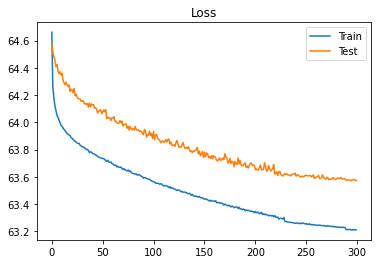

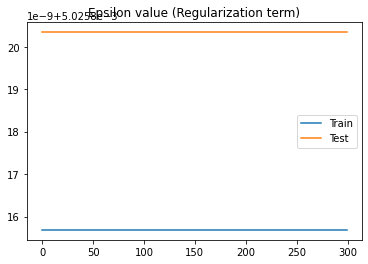

elapsed_time:  280.03151988983154
Train: average propensity for t=0: 0.07006587833166122, t=1: 0.074427030980587, t=2: 0.08700781315565109, t=3: 0.09625163674354553, t=4: 0.1087951809167862
Test: average propensity for t=0: 0.07247859239578247, t=1: 0.06957659125328064, t=2: 0.08595550805330276, t=3: 0.09465454518795013, t=4: 0.1104554608464241
*****************************
Is targeted regularization: True
I am here making dragonnet


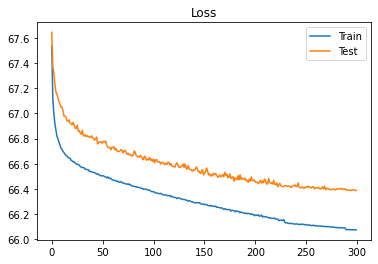

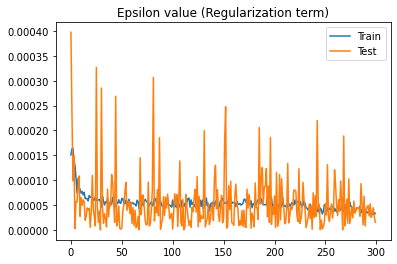

elapsed_time:  321.6407301425934
Train: average propensity for t=0: 0.07094289362430573, t=1: 0.07736177742481232, t=2: 0.09040827304124832, t=3: 0.09816445410251617, t=4: 0.11213062703609467
Test: average propensity for t=0: 0.07307610660791397, t=1: 0.07263807207345963, t=2: 0.0891873762011528, t=3: 0.09645242244005203, t=4: 0.11397827416658401
*****************************
Is targeted regularization: False
I am here making dragonnet


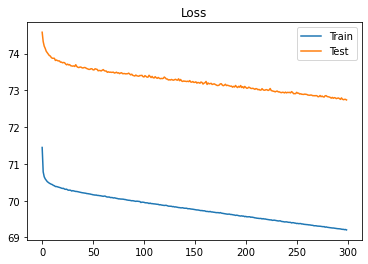

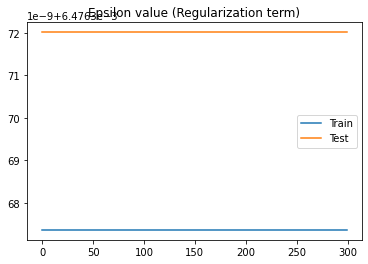

elapsed_time:  251.4850573539734
Train: average propensity for t=0: 0.06906552612781525, t=1: 0.08077849447727203, t=2: 0.08967678993940353, t=3: 0.09892741590738297, t=4: 0.11440714448690414
Test: average propensity for t=0: 0.07113610208034515, t=1: 0.0766005590558052, t=2: 0.08882398903369904, t=3: 0.09680482745170593, t=4: 0.11605632305145264
*****************************
Is targeted regularization: True
I am here making dragonnet


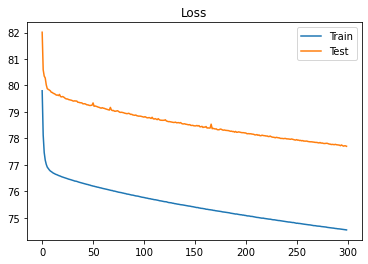

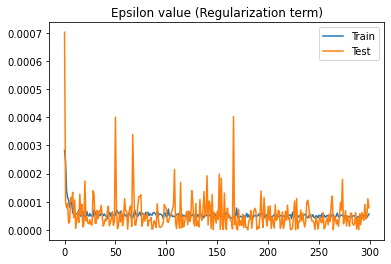

elapsed_time:  288.1623229980469
Train: average propensity for t=0: 0.06902660429477692, t=1: 0.08026625961065292, t=2: 0.09017878025770187, t=3: 0.09886223822832108, t=4: 0.1159452423453331
Test: average propensity for t=0: 0.0700094923377037, t=1: 0.07741358876228333, t=2: 0.08890984207391739, t=3: 0.09734247624874115, t=4: 0.11726605147123337
*****************************
Is targeted regularization: False
I am here making dragonnet


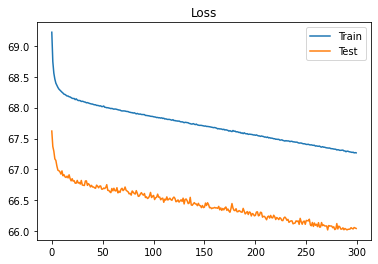

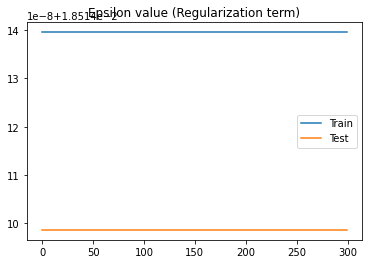

elapsed_time:  260.1458194255829
Train: average propensity for t=0: 0.07321390509605408, t=1: 0.0760493278503418, t=2: 0.08968742191791534, t=3: 0.09917110204696655, t=4: 0.11512848734855652
Test: average propensity for t=0: 0.07589107006788254, t=1: 0.07067225128412247, t=2: 0.08807098865509033, t=3: 0.09787563234567642, t=4: 0.11669942736625671
*****************************
Is targeted regularization: True
I am here making dragonnet


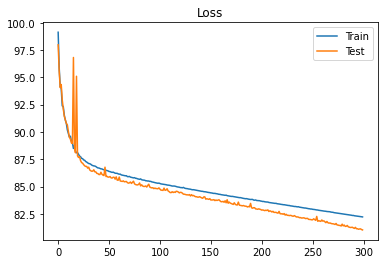

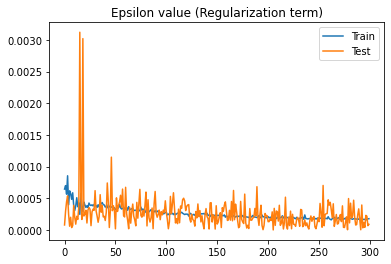

elapsed_time:  294.5357348918915
Train: average propensity for t=0: 0.07066842168569565, t=1: 0.07510752230882645, t=2: 0.08754011243581772, t=3: 0.10141909867525101, t=4: 0.11749503761529922
Test: average propensity for t=0: 0.07047512382268906, t=1: 0.07295931130647659, t=2: 0.08545222133398056, t=3: 0.10135766863822937, t=4: 0.11776067316532135
*****************************
Is targeted regularization: False
I am here making dragonnet


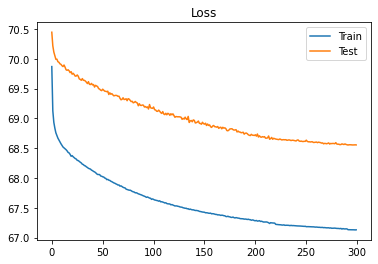

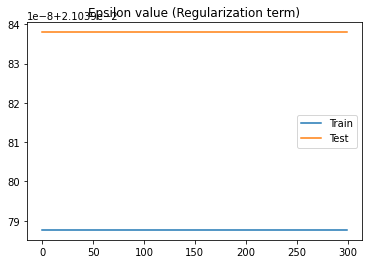

elapsed_time:  259.37846851348877
Train: average propensity for t=0: 0.06911680847406387, t=1: 0.07866266369819641, t=2: 0.09038619697093964, t=3: 0.09640737622976303, t=4: 0.11361201852560043
Test: average propensity for t=0: 0.07110299915075302, t=1: 0.07378563284873962, t=2: 0.08909878879785538, t=3: 0.09476335346698761, t=4: 0.11535509675741196
*****************************
Is targeted regularization: True
I am here making dragonnet


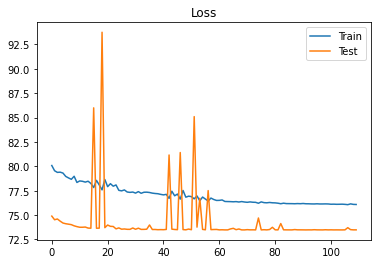

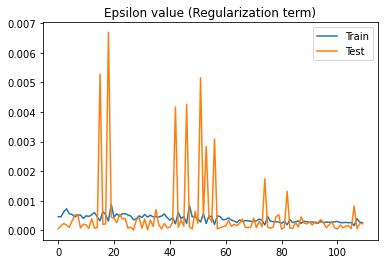

elapsed_time:  123.11357021331787
Train: average propensity for t=0: 0.06968176364898682, t=1: 0.0771932601928711, t=2: 0.08925871551036835, t=3: 0.09631909430027008, t=4: 0.11441405117511749
Test: average propensity for t=0: 0.07022147625684738, t=1: 0.0745566114783287, t=2: 0.08768041431903839, t=3: 0.09515926241874695, t=4: 0.11559460312128067
*****************************
Is targeted regularization: False
I am here making dragonnet


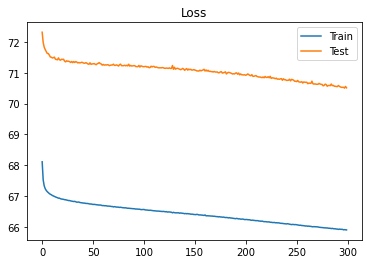

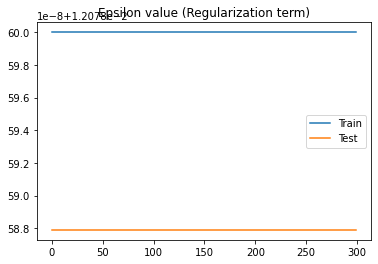

elapsed_time:  277.0123505592346
Train: average propensity for t=0: 0.07164470851421356, t=1: 0.07934132218360901, t=2: 0.09124185889959335, t=3: 0.09717200696468353, t=4: 0.11067300289869308
Test: average propensity for t=0: 0.07394441962242126, t=1: 0.07470915466547012, t=2: 0.09009058773517609, t=3: 0.09506269544363022, t=4: 0.11277053505182266
*****************************
Is targeted regularization: True
I am here making dragonnet


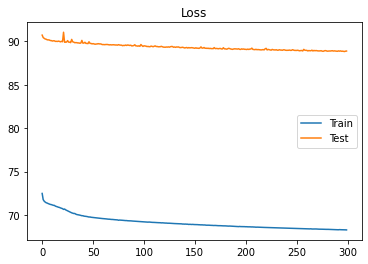

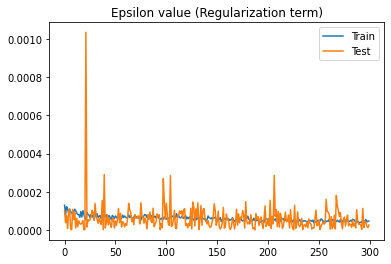

elapsed_time:  301.9471983909607
Train: average propensity for t=0: 0.07052626460790634, t=1: 0.07790082693099976, t=2: 0.089084193110466, t=3: 0.09698761999607086, t=4: 0.1106782928109169
Test: average propensity for t=0: 0.07213354855775833, t=1: 0.07433400303125381, t=2: 0.0878520980477333, t=3: 0.0951685681939125, t=4: 0.11237768083810806
*****************************
Is targeted regularization: False
I am here making dragonnet


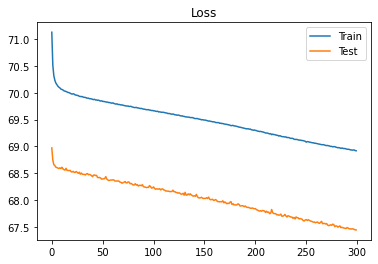

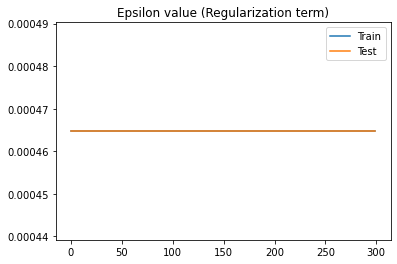

elapsed_time:  305.7565031051636
Train: average propensity for t=0: 0.07253532856702805, t=1: 0.08000491559505463, t=2: 0.09302674978971481, t=3: 0.09431322664022446, t=4: 0.10005605965852737
Test: average propensity for t=0: 0.07512464374303818, t=1: 0.07490584254264832, t=2: 0.09142490476369858, t=3: 0.09222018718719482, t=4: 0.10262429714202881
*****************************
Is targeted regularization: True
I am here making dragonnet


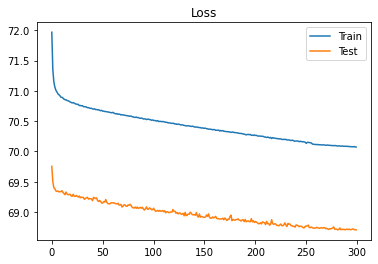

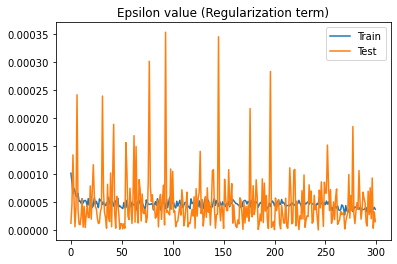

elapsed_time:  315.8949615955353
Train: average propensity for t=0: 0.07095665484666824, t=1: 0.07821828871965408, t=2: 0.09266874194145203, t=3: 0.0946766808629036, t=4: 0.10097154974937439
Test: average propensity for t=0: 0.07307903468608856, t=1: 0.07389930635690689, t=2: 0.09099265187978745, t=3: 0.0927717536687851, t=4: 0.10328759253025055
*****************************
Is targeted regularization: False
I am here making dragonnet


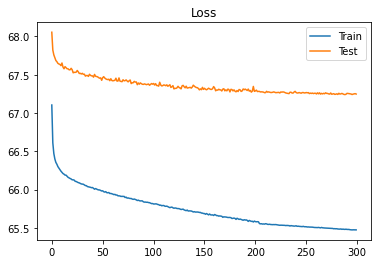

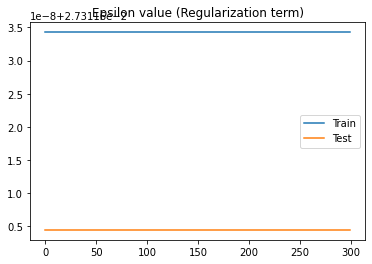

elapsed_time:  265.07424998283386
Train: average propensity for t=0: 0.06955026835203171, t=1: 0.07769344002008438, t=2: 0.08879464119672775, t=3: 0.09621942043304443, t=4: 0.11094269156455994
Test: average propensity for t=0: 0.07200106978416443, t=1: 0.0727381706237793, t=2: 0.08778399974107742, t=3: 0.0945843830704689, t=4: 0.11279119551181793
*****************************
Is targeted regularization: True
I am here making dragonnet


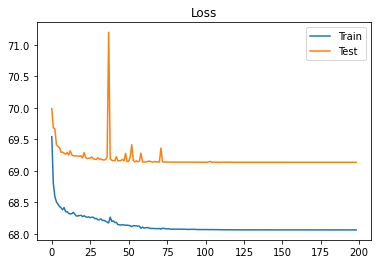

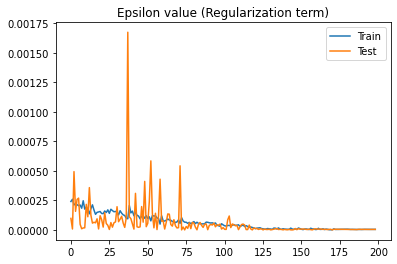

elapsed_time:  212.59805536270142
Train: average propensity for t=0: 0.06974723190069199, t=1: 0.07804831862449646, t=2: 0.09039491415023804, t=3: 0.09814940392971039, t=4: 0.11284905672073364
Test: average propensity for t=0: 0.07192343473434448, t=1: 0.07338856160640717, t=2: 0.08923322707414627, t=3: 0.09682372957468033, t=4: 0.11442629247903824
*****************************
Is targeted regularization: False
I am here making dragonnet


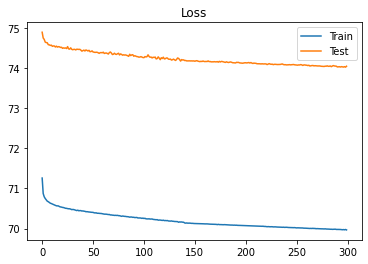

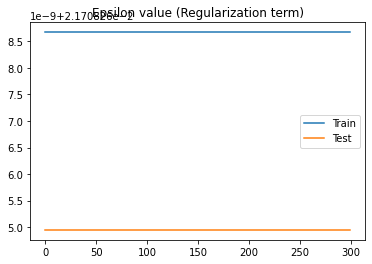

elapsed_time:  254.4986355304718
Train: average propensity for t=0: 0.070832259953022, t=1: 0.08373662829399109, t=2: 0.09140214323997498, t=3: 0.09689433872699738, t=4: 0.11412883549928665
Test: average propensity for t=0: 0.07332641631364822, t=1: 0.07911589741706848, t=2: 0.09037559479475021, t=3: 0.09570419043302536, t=4: 0.11529757082462311
*****************************
Is targeted regularization: True
I am here making dragonnet


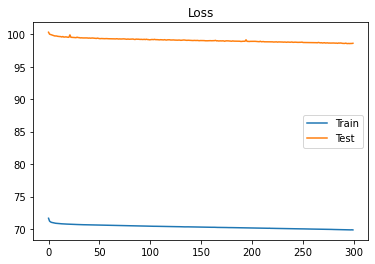

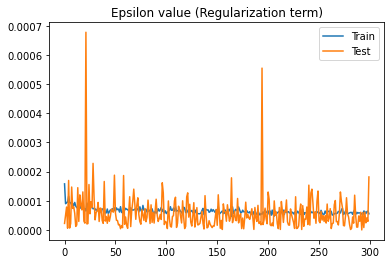

elapsed_time:  301.03822469711304
Train: average propensity for t=0: 0.07093914598226547, t=1: 0.08375705778598785, t=2: 0.09126497060060501, t=3: 0.09681746363639832, t=4: 0.11435354501008987
Test: average propensity for t=0: 0.07379035651683807, t=1: 0.07889619469642639, t=2: 0.09003502130508423, t=3: 0.09570417553186417, t=4: 0.115471750497818
*****************************
Is targeted regularization: False
I am here making dragonnet


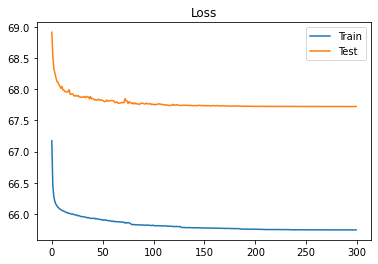

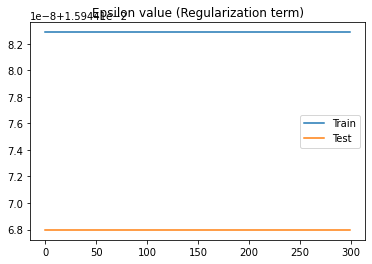

elapsed_time:  265.38442969322205
Train: average propensity for t=0: 0.07022760808467865, t=1: 0.07733076810836792, t=2: 0.08790156990289688, t=3: 0.09962712973356247, t=4: 0.11123008280992508
Test: average propensity for t=0: 0.07316529750823975, t=1: 0.07205937802791595, t=2: 0.08649096637964249, t=3: 0.097626231610775, t=4: 0.11344645172357559
*****************************
Is targeted regularization: True
I am here making dragonnet


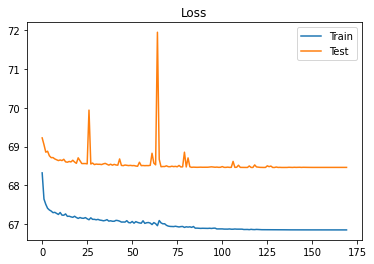

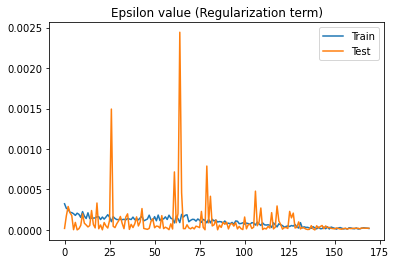

elapsed_time:  184.52100729942322
Train: average propensity for t=0: 0.07021977007389069, t=1: 0.07710376381874084, t=2: 0.08777979016304016, t=3: 0.0997302234172821, t=4: 0.11111361533403397
Test: average propensity for t=0: 0.07293874025344849, t=1: 0.07208852469921112, t=2: 0.086267851293087, t=3: 0.09789691865444183, t=4: 0.11330033838748932
*****************************
Is targeted regularization: False
I am here making dragonnet


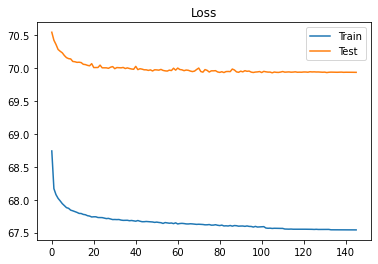

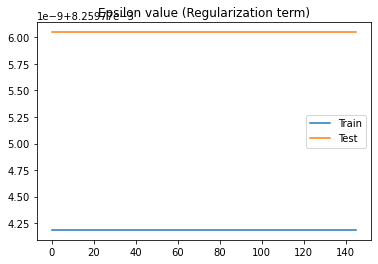

elapsed_time:  142.3688440322876
Train: average propensity for t=0: 0.0709717646241188, t=1: 0.07952721416950226, t=2: 0.09015396982431412, t=3: 0.09975923597812653, t=4: 0.11478245258331299
Test: average propensity for t=0: 0.07330815494060516, t=1: 0.07508517801761627, t=2: 0.08912988752126694, t=3: 0.09786967188119888, t=4: 0.11682356894016266
*****************************
Is targeted regularization: True
I am here making dragonnet


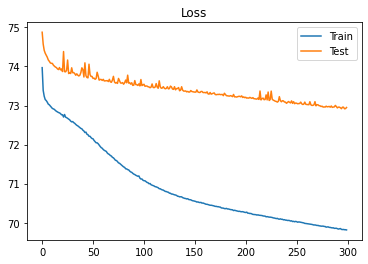

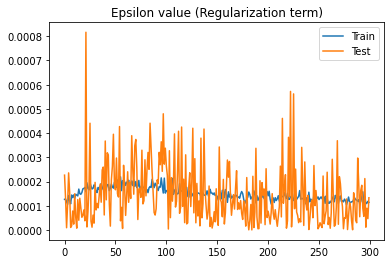

elapsed_time:  298.44482612609863
Train: average propensity for t=0: 0.06952166557312012, t=1: 0.07798542827367783, t=2: 0.08884021639823914, t=3: 0.09716848284006119, t=4: 0.11266665160655975
Test: average propensity for t=0: 0.07120365649461746, t=1: 0.07431581616401672, t=2: 0.08804547786712646, t=3: 0.09544473141431808, t=4: 0.11480802297592163
*****************************
Is targeted regularization: False
I am here making dragonnet


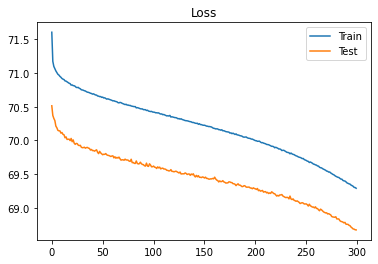

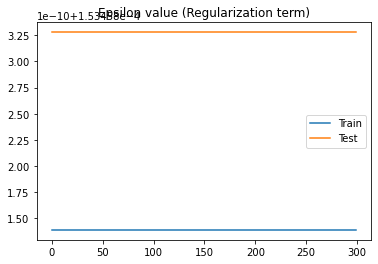

elapsed_time:  260.17463302612305
Train: average propensity for t=0: 0.07078375667333603, t=1: 0.07981378585100174, t=2: 0.09196360409259796, t=3: 0.10008940100669861, t=4: 0.1006031185388565
Test: average propensity for t=0: 0.0727984607219696, t=1: 0.07528106123209, t=2: 0.09094445407390594, t=3: 0.09870647639036179, t=4: 0.10222900658845901
*****************************
Is targeted regularization: True
I am here making dragonnet


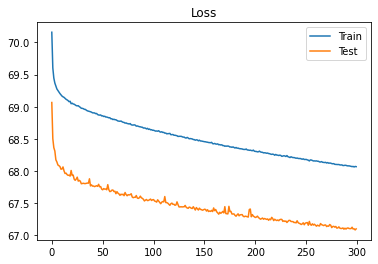

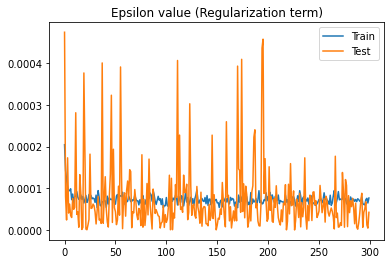

elapsed_time:  306.6554946899414
Train: average propensity for t=0: 0.06896388530731201, t=1: 0.07675925642251968, t=2: 0.08969173580408096, t=3: 0.09861715137958527, t=4: 0.10894186794757843
Test: average propensity for t=0: 0.07056547701358795, t=1: 0.07301874458789825, t=2: 0.08857741951942444, t=3: 0.09714722633361816, t=4: 0.11050328612327576
*****************************
Is targeted regularization: False
I am here making dragonnet


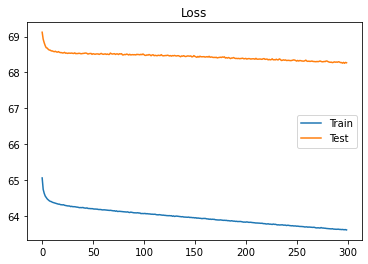

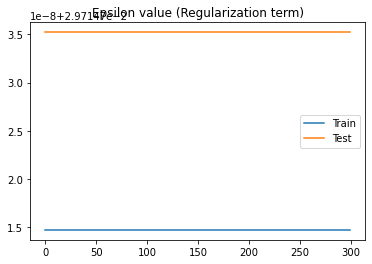

elapsed_time:  269.24112486839294
Train: average propensity for t=0: 0.0724579468369484, t=1: 0.07853232324123383, t=2: 0.0885654017329216, t=3: 0.09488637000322342, t=4: 0.11501490324735641
Test: average propensity for t=0: 0.07481113076210022, t=1: 0.07397935539484024, t=2: 0.08706742525100708, t=3: 0.09334246814250946, t=4: 0.11669756472110748
*****************************
Is targeted regularization: True
I am here making dragonnet


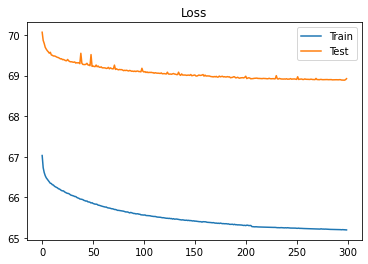

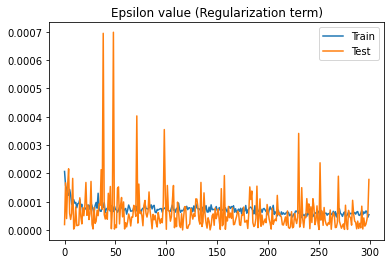

elapsed_time:  302.9988811016083
Train: average propensity for t=0: 0.0721605122089386, t=1: 0.07804705947637558, t=2: 0.08837883174419403, t=3: 0.09525324404239655, t=4: 0.11552131921052933
Test: average propensity for t=0: 0.0746079832315445, t=1: 0.07356931269168854, t=2: 0.08697298914194107, t=3: 0.09380566328763962, t=4: 0.11703812330961227
*****************************
Is targeted regularization: False
I am here making dragonnet


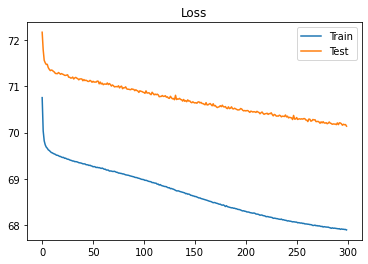

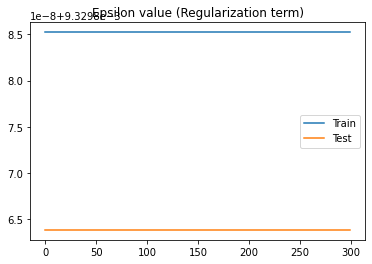

elapsed_time:  260.1695649623871
Train: average propensity for t=0: 0.06967074424028397, t=1: 0.08010038733482361, t=2: 0.09065180271863937, t=3: 0.09516032785177231, t=4: 0.11418212205171585
Test: average propensity for t=0: 0.0716824010014534, t=1: 0.07610318064689636, t=2: 0.08929738402366638, t=3: 0.09311563521623611, t=4: 0.11587633192539215
*****************************
Is targeted regularization: True
I am here making dragonnet


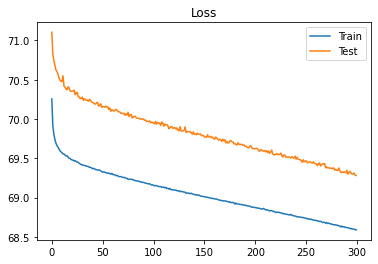

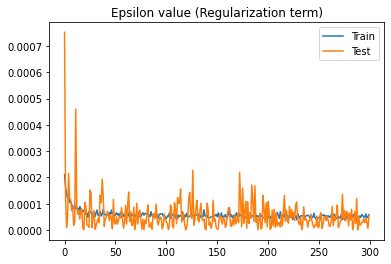

elapsed_time:  298.3196039199829
Train: average propensity for t=0: 0.06984009593725204, t=1: 0.07940945029258728, t=2: 0.09154114127159119, t=3: 0.09492673724889755, t=4: 0.11456332355737686
Test: average propensity for t=0: 0.07186795026063919, t=1: 0.07524170726537704, t=2: 0.09030499309301376, t=3: 0.09259738028049469, t=4: 0.11587359011173248
*****************************
Is targeted regularization: False
I am here making dragonnet


In [ ]:
#with tf.device('GPU:0'):
#    run_ihdp(dragon='dragonnet', ratio=10, verbose=0) # ratio is the beta parameter of the targeted regularization loss function
print_flag = False
    
#for nconf in [4,8,12,16]:
for nconf in [20]:
    with tf.device('GPU:0'):
        run_ihdp(data_base_dir='/home/bvelasco/PhD/Dragonnet/dragonnet/dat/ihdp/eight_case/conf_{}'.format(nconf),
                 output_dir='/home/bvelasco/PhD/Dragonnet/dragonnet/result/ihdp_8/conf_{}/'.format(nconf),
                 dragon='dragonnet', ratio=5, print_model_flag=print_flag) # ratio is the beta parameter of the targeted regularization loss function
        print_flag=False

## ATE Estimation

### Auxiliary functions

In [1]:
import pandas as pd
import numpy as np
from scipy.special import logit
import sklearn.linear_model as lm
from joblib import Parallel, delayed # for parallel processing


import sys
#!{sys.executable} -m pip install scipy==1.7.1

from scipy.stats import bootstrap

In [2]:

def calibrate_g(g, t):
    """
    Improve calibration of propensity scores by fitting 1 parameter (temperature) logistic regression on heldout data

    :param g: raw propensity score estimates
    :param t: treatment assignments
    :return:
    """

    logit_g = logit(g).reshape(-1,1)
    calibrator = lm.LogisticRegression(fit_intercept=False, C=1e6)  # no intercept or regularization
    calibrator.fit(logit_g, t)
    calibrated_g = calibrator.predict_proba(logit_g)[:,1]
    return calibrated_g


def truncate_by_g(attribute, g, level=0.01):
    if level==0.:
        return attribute
    else:
        keep_these = np.logical_and(g >= level, g <= 1.-level)
        return attribute[keep_these]


def truncate_all_by_g(q_t0, q_t1, q_t2, g, t, y, truncate_level=0.05):
    """
    Helper function to clean up nuisance parameter estimates.

    """

    orig_g = np.copy(g)

    q_t0 = truncate_by_g(np.copy(q_t0), orig_g, truncate_level)
    q_t1 = truncate_by_g(np.copy(q_t1), orig_g, truncate_level)
    q_t2 = truncate_by_g(np.copy(q_t2), orig_g, truncate_level)
    g = truncate_by_g(np.copy(g), orig_g, truncate_level)
    t = truncate_by_g(np.copy(t), orig_g, truncate_level)
    y = truncate_by_g(np.copy(y), orig_g, truncate_level)

    return q_t0, q_t1, q_t2, g, t, y



def cross_entropy(y, p):
    return -np.mean((y*np.log(p) + (1.-y)*np.log(1.-p)))


def mse(x, y):
    return np.mean(np.square(x-y))

### Estimators

In [3]:
def _perturbed_model_bin_outcome(q_t0, q_t1, g, t, eps): # Not adapted for trinary case
    """
    Helper for psi_tmle_bin_outcome

    Returns q_\eps (t,x)
    (i.e., value of perturbed predictor at t, eps, x; where q_t0, q_t1, g are all evaluated at x
    """
    h = t * (1./g) - (1.-t) / (1. - g)
    full_lq = (1.-t)*logit(q_t0) + t*logit(q_t1)  # logit predictions from unperturbed model
    logit_perturb = full_lq + eps * h
    return expit(logit_perturb)


def psi_tmle_bin_outcome(q_t0, q_t1, g, t, y, truncate_level=0.05): # Not adapted for trinary case
    # TODO: make me usable
    # solve the perturbation problem

    q_t0, q_t1, g, t, y = truncate_all_by_g(q_t0, q_t1, g, t, y, truncate_level)

    eps_hat = minimize(lambda eps: cross_entropy(y, _perturbed_model_bin_outcome(q_t0, q_t1, g, t, eps))
                       , 0., method='Nelder-Mead')

    eps_hat = eps_hat.x[0]

    def q1(t_cf):
        return _perturbed_model_bin_outcome(q_t0, q_t1, g, t_cf, eps_hat)

    ite = q1(np.ones_like(t)) - q1(np.zeros_like(t))
    return np.mean(ite)


def psi_tmle_cont_outcome(q_t0, q_t1, g, t, y, eps_hat=None, truncate_level=0.05): # Not adapted for trinary case
    q_t0, q_t1, g, t, y = truncate_all_by_g(q_t0, q_t1, g, t, y, truncate_level)


    g_loss = mse(g, t)
    h = t * (1.0/g) - (1.0-t) / (1.0 - g)
    full_q = (1.0-t)*q_t0 + t*q_t1 # predictions from unperturbed model

    if eps_hat is None:
        eps_hat = np.sum(h*(y-full_q)) / np.sum(np.square(h))

    def q1(t_cf):
        h_cf = t_cf * (1.0 / g) - (1.0 - t_cf) / (1.0 - g)
        full_q = (1.0 - t_cf) * q_t0 + t_cf * q_t1  # predictions from unperturbed model
        return full_q + eps_hat * h_cf

    ite = q1(np.ones_like(t)) - q1(np.zeros_like(t))
    psi_tmle = np.mean(ite)

    # standard deviation computation relies on asymptotic expansion of non-parametric estimator, see van der Laan and Rose p 96
    ic = h*(y-q1(t)) + ite - psi_tmle
    psi_tmle_std = np.std(ic) / np.sqrt(t.shape[0])
    initial_loss = np.mean(np.square(full_q-y))
    final_loss = np.mean(np.square(q1(t)-y))


    return psi_tmle, psi_tmle_std, eps_hat, initial_loss, final_loss, g_loss


def psi_iptw(q_t0, q_t1, g, t, y, truncate_level=0.05): # Not adapted for trinary case
    ite=(t / g - (1-t) / (1-g))*y
    return np.mean(truncate_by_g(ite, g, level=truncate_level))


def psi_aiptw(q_t0, q_t1, q_t2, g, t, y, truncate_level=0.05): # Not adapted for trinary case
    q_t0, q_t1, q_t2, g, t, y = truncate_all_by_g(q_t0, q_t1, g, t, y, truncate_level)

    full_q = q_t0 * (1 - t) + q_t1 * t
    h = t * (1.0 / g) - (1.0 - t) / (1.0 - g)
    ite = h * (y - full_q) + q_t1 - q_t0

    return np.mean(ite)


def psi_naive(q_t0, q_t1, q_t2, q_t3, q_t4, q_t5, q_t6, q_t7, g, t, y, truncate_level=0.): # Adapted 
    ite1_0 = (q_t1 - q_t0)
    ite2_0 = (q_t2 - q_t0)
    ite3_0 = (q_t3 - q_t0)
    ite4_0 = (q_t4 - q_t0)
    ite5_0 = (q_t5 - q_t0)
    ite6_0 = (q_t6 - q_t0)
    ite7_0 = (q_t7 - q_t0)

    
    ite1_0 = np.mean(truncate_by_g(ite1_0, g, level=truncate_level))
    ite2_0 = np.mean(truncate_by_g(ite2_0, g, level=truncate_level))
    ite3_0 = np.mean(truncate_by_g(ite3_0, g, level=truncate_level))
    ite4_0 = np.mean(truncate_by_g(ite4_0, g, level=truncate_level))
    ite5_0 = np.mean(truncate_by_g(ite5_0, g, level=truncate_level))
    ite6_0 = np.mean(truncate_by_g(ite6_0, g, level=truncate_level))
    ite7_0 = np.mean(truncate_by_g(ite7_0, g, level=truncate_level))

    #return np.mean(truncate_by_g(ite, g, level=truncate_level))
    return [ite1_0, ite2_0, ite3_0, ite4_0, ite5_0, ite6_0, ite7_0]


def psi_very_naive(y, t, truncate_level=0.): # Adapted 
    y1_0 = y[t == 1].mean() - y[t == 0].mean()
    y2_0 = y[t == 2].mean() - y[t == 0].mean()
    y3_0 = y[t == 3].mean() - y[t == 0].mean()
    y4_0 = y[t == 4].mean() - y[t == 0].mean()
    y5_0 = y[t == 5].mean() - y[t == 0].mean()
    y6_0 = y[t == 6].mean() - y[t == 0].mean()
    y7_0 = y[t == 7].mean() - y[t == 0].mean()



    #return y[t == 1].mean() - y[t == 0].mean()
    return [y1_0, y2_0, y3_0, y4_0, y5_0, y6_0, y7_0]

def ates_from_atts(q_t0, q_t1, g, t, y, truncate_level=0.05): # Not adapted for trinary
    """
    Sanity check code: ATE = ATT_1*P(T=1) + ATT_0*P(T=1)

    :param q_t0:
    :param q_t1:
    :param g:
    :param t:
    :param y:
    :param truncate_level:
    :return:
    """

    prob_t = t.mean()

    att = att_estimates(q_t0, q_t1, g, t, y, prob_t, truncate_level=truncate_level)
    atnott = att_estimates(q_t1, q_t0, 1.-g, 1-t, y, 1.-prob_t, truncate_level=truncate_level)

    att['one_step_tmle'] = att['one_step_tmle'][0]
    atnott['one_step_tmle'] = atnott['one_step_tmle'][0]

    ates = {}
    for k in att.keys():
        ates[k] = att[k]*prob_t + atnott[k]*(1.-prob_t)

    return ates

### Data loader

In [4]:
import copy
from numpy import load


def load_truth(replication, nconf):
    """
    loading ground truth data
    """

    file_path = '/home/bvelasco/PhD/Dragonnet/dragonnet/result/ihdp_8/conf_{}/{}/simulation_outputs.npz'.format(nconf, replication)
    data = load(file_path)
    mu_0 = data['mu_0']
    mu_1 = data['mu_1']
    mu_2 = data['mu_2']
    mu_3 = data['mu_3']
    mu_4 = data['mu_4']
    mu_5 = data['mu_5']
    mu_6 = data['mu_6']
    mu_7 = data['mu_7']

    
    return mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7


def load_data(replication=1, model='baseline', train_test='test', nconf=8):
    """
    loading train test experiment results
    """

    file_path = '/home/bvelasco/PhD/Dragonnet/dragonnet/result/ihdp_8/conf_{}/'.format(nconf)
    data = load(file_path + '{}/{}/0_replication_{}.npz'.format(replication, model, train_test))

    return data['q_t0'].reshape(-1, 1), data['q_t1'].reshape(-1, 1), data['q_t2'].reshape(-1, 1), data['q_t3'].reshape(-1, 1), data['q_t4'].reshape(-1, 1), \
            data['q_t5'].reshape(-1, 1), data['q_t6'].reshape(-1, 1), data['q_t7'].reshape(-1, 1), data['g'].reshape(-1, 1), \
            data['t'].reshape(-1, 1), data['y'].reshape(-1, 1), data['index'].reshape(-1, 1), data['eps'].reshape(-1, 1)


def get_estimate(q_t0, q_t1, q_t2, q_t3, q_t4, q_t5, q_t6, q_t7, g, t, y_dragon, index, eps, truncate_level=0.01):
    """
    getting the back door adjustment & TMLE estimation
    """

    psi_n = psi_naive(q_t0, q_t1, q_t2, q_t3, q_t4, q_t5, q_t6, q_t7, g, t, y_dragon, truncate_level=truncate_level)
    #psi_tmle, psi_tmle_std, eps_hat, initial_loss, final_loss, g_loss = psi_tmle_cont_outcome(q_t0, q_t1, g, t,
    #                                                                                          y_dragon,
    #                                                                                          truncate_level=truncate_level)
    psi_vn = psi_very_naive(y_dragon, t)
    #return psi_vn, initial_loss, final_loss, g_loss
    return psi_vn, psi_n


### Caller for getting estimations

In [8]:
def make_table(train_test='test', n_replication=49, nconf=8):

    
    result_dict = {'N. confounders': [], 'Avg true value': [], 'Avg biased estimate': [], 'Naive estimator error': [],
                   'baseline': {'Avg hydranet est.': [], 'Hydranet error': []},
                   'targeted_regularization': { 'Avg hydranet est.': [], 'Hydranet error': []},
                   'Other params': [],
                 }
    
    estim_dict = {
            'baseline': [], 'targeted_regularization': []
            }
    

    for model in ['baseline','targeted_regularization']:
        true_val, biased_val, biased_estim = [], [], []
        temp = []
        for rep in range(n_replication):
            q_t0, q_t1, q_t2, q_t3, q_t4, q_t5, q_t6, q_t7, g, t, y_dragon, index, eps = load_data(rep, model, train_test, nconf)
            a, b, c, d, e, f, g, h = load_truth(rep, nconf)
            mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7 = a[index], b[index], c[index], d[index], e[index], f[index], g[index], h[index]
            
            #mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7 = a, b, c, d, e, f, g, h

            truth1_0 = (mu_1 - mu_0).mean()
            truth2_0 = (mu_2 - mu_0).mean()
            truth3_0 = (mu_3 - mu_0).mean()
            truth4_0 = (mu_4 - mu_0).mean()
            truth5_0 = (mu_5 - mu_0).mean()
            truth6_0 = (mu_6 - mu_0).mean()
            truth7_0 = (mu_7 - mu_0).mean()

            biased1_0 = y_dragon[t==1].mean() - y_dragon[t==0].mean()
            biased2_0 = y_dragon[t==2].mean() - y_dragon[t==0].mean()
            biased3_0 = y_dragon[t==3].mean() - y_dragon[t==0].mean()
            biased4_0 = y_dragon[t==4].mean() - y_dragon[t==0].mean()
            biased5_0 = y_dragon[t==5].mean() - y_dragon[t==0].mean()
            biased6_0 = y_dragon[t==6].mean() - y_dragon[t==0].mean()
            biased7_0 = y_dragon[t==7].mean() - y_dragon[t==0].mean()
            

            psi_vn, psi_n = get_estimate(q_t0, q_t1, q_t2, q_t3, q_t4, q_t5, q_t6, q_t7, g, t, y_dragon, index, eps, truncate_level=0.)

            true_val.append([truth1_0, truth2_0, truth3_0, truth4_0, truth5_0, truth6_0, truth7_0])
            biased_val.append([biased1_0, biased2_0, biased3_0, biased4_0, biased5_0, biased6_0, biased7_0])
            estim_dict[model].append(psi_n)
            #print(np.mean(mu_1))
            
        # Compute error, from average true and average estimated values
        true_val = np.asarray(true_val)
        biased_val = np.asarray(biased_val)
        
        biased_error = abs(true_val - biased_val).sum(axis=1) #change to sum
        biased_error_val = biased_error.mean()
        hydranet_error = abs(estim_dict[model] - true_val).sum(axis=1)
        hydranet_error_val = hydranet_error.mean()
        
        # Check big-small error t-reg difference
        ####################################################
        '''if model=='baseline':
            baseline_low = np.where(hydranet_error<hydranet_error_val)[0]
            baseline_high = np.where(hydranet_error>hydranet_error_val)[0]
        
        hydranet_error = hydranet_error[baseline_high]
        hydranet_error_val = hydranet_error.mean()'''
        ####################################################
        
        # Compute error, from average true and average estimated values
        result_dict['N. confounders'] = nconf
        result_dict['Avg true value'] = np.mean(true_val, axis=0)
        result_dict['Avg biased estimate'] = np.mean(biased_val, axis=0)
        result_dict['Naive estimator error'] = biased_error_val
        result_dict[model]['Avg hydranet est.'] = np.mean(estim_dict[model], axis=0)
        result_dict[model]['Hydranet error'] = hydranet_error_val
        
        
        # Compute bootstrap 95% CI intervals for the error
        alg_name = '{} est error CIs'.format(model)
        naive_ci_l, naive_ci_u = bootstrap((biased_error,), statistic=np.mean, method='basic', random_state = 3).confidence_interval
        hydra_ci_l, hydra_ci_u = bootstrap((hydranet_error,), statistic=np.mean, method='basic', random_state = 3).confidence_interval
        result_dict['Naive est error CIs'] = naive_ci_l, naive_ci_u
        result_dict[alg_name] = hydra_ci_l, hydra_ci_u

    return result_dict

In [9]:
# Parallelize
result_table = []
result_table.append(Parallel(n_jobs=20)(delayed(make_table)(train_test='test', nconf=nconf)
                   for nconf in [4,8,12,16,20]))
pd.DataFrame(result_table[0]).to_csv('/home/bvelasco/PhD/Dragonnet/dragonnet/result/ihdp_8/results_{}.csv'.format('test'))

In [7]:
#for data_set in ['test']:
#    result_table = []
#    for nconf in [4,8,12,16]:
#        result_table.append(make_table(train_test=data_set, n_replication=80, nconf=nconf))
    #pd.DataFrame(result_table).to_csv('/home/bvelasco/PhD/Dragonnet/dragonnet/result/ihdp_8/results_{}.csv'.format(data_set))

In [7]:
result_table

[[{'N. confounders': 4,
   'Avg true value': array([ -3.80659344,  -1.55654062,  15.38890931,  50.63122089,
           98.75519284, 156.26847546, 220.75564068]),
   'Avg biased estimate': array([ -3.75132606,  -3.77842846,  12.74100023,  53.48321173,
          106.10051786, 160.95290372, 220.28687944]),
   'Naive estimator error': 60.19206947874314,
   'baseline': {'Avg hydranet est.': array([ -0.2988113,   2.0192552,  17.694017 ,  52.991306 , 101.10269  ,
           158.6245   , 223.04955  ], dtype=float32),
    'Hydranet error': 22.71763655833771},
   'targeted_regularization': {'Avg hydranet est.': array([-8.8917889e-02,  1.7029618e+00,  2.0188734e+01,  5.5015186e+01,
            1.0334176e+02,  1.6097040e+02,  2.2571281e+02], dtype=float32),
    'Hydranet error': 37.4741409733981},
   'Other params': [],
   'Naive est error CIs': (33.2342375918693, 81.1305464022046),
   'baseline est error CIs': (18.594720028237123, 26.70038412446646),
   'targeted_regularization est error CIs': (3

# SAVE RAW DATA (ONLY TEST SET)

In [17]:
def results_raw(n_replication=80):
    
    
    estim_dict = {
            'baseline': [], 'targeted_regularization': []
            }
    
    raw_data = pd.DataFrame(columns=['nconf',
                         'model',
                        'TATE1_0',
                        'TATE2_0',
                        'TATE3_0',
                        'TATE4_0',
                        'TATE5_0',
                        'TATE6_0',
                        'TATE7_0',
                        'Naive_ATE1_0',
                        'Naive_ATE2_0',
                        'Naive_ATE3_0',
                        'Naive_ATE4_0',
                        'Naive_ATE5_0',
                        'Naive_ATE6_0',
                        'Naive_ATE7_0',
                        'Naive_err_0',
                        'Naive_err_1',
                        'Naive_err_2',
                        'Naive_err_3',
                        'Naive_err_4',
                        'Naive_err_5',
                        'Naive_err_6',
                        'Hydranet_ATE1_0',
                        'Hydranet_ATE2_0',
                        'Hydranet_ATE3_0',
                        'Hydranet_ATE4_0',
                        'Hydranet_ATE5_0',
                        'Hydranet_ATE6_0',
                        'Hydranet_ATE7_0',
                        'Hydranet_err_0',
                        'Hydranet_err_1',
                        'Hydranet_err_2',
                        'Hydranet_err_3',
                        'Hydranet_err_4',
                        'Hydranet_err_5',
                        'Hydranet_err_6'])
    
    train_test='test'
    
    for nconf in [4,8,12,16]:
        for model in ['baseline', 'targeted_regularization']:
            true_val, biased_val, biased_estim, estim_dict[model] = [], [], [], []
            for rep in range(n_replication):
                q_t0, q_t1, q_t2, q_t3, q_t4, q_t5, q_t6, q_t7, g, t, y_dragon, index, eps = load_data(rep, model, train_test, nconf)
                a, b, c, d, e, f, g, h = load_truth(rep, nconf)
                mu_0, mu_1, mu_2, mu_3, mu_4, mu_5, mu_6, mu_7 = a[index], b[index], c[index], d[index], e[index], f[index], g[index], h[index]

                data_len = len(y_dragon)

                truth1_0 = (mu_1 - mu_0).mean()
                truth2_0 = (mu_2 - mu_0).mean()
                truth3_0 = (mu_3 - mu_0).mean()
                truth4_0 = (mu_4 - mu_0).mean()
                truth5_0 = (mu_5 - mu_0).mean()
                truth6_0 = (mu_6 - mu_0).mean()
                truth7_0 = (mu_7 - mu_0).mean()

                biased1_0 = y_dragon[t==1].mean() - y_dragon[t==0].mean()
                biased2_0 = y_dragon[t==2].mean() - y_dragon[t==0].mean()
                biased3_0 = y_dragon[t==3].mean() - y_dragon[t==0].mean()
                biased4_0 = y_dragon[t==4].mean() - y_dragon[t==0].mean()
                biased5_0 = y_dragon[t==5].mean() - y_dragon[t==0].mean()
                biased6_0 = y_dragon[t==6].mean() - y_dragon[t==0].mean()
                biased7_0 = y_dragon[t==7].mean() - y_dragon[t==0].mean()


                psi_vn, psi_n = get_estimate(q_t0, q_t1, q_t2, q_t3, q_t4, q_t5, q_t6, q_t7, g, t, y_dragon, index, eps, truncate_level=0.)

                true_val.append([truth1_0, truth2_0, truth3_0, truth4_0, truth5_0, truth6_0, truth7_0])
                biased_val.append([biased1_0, biased2_0, biased3_0, biased4_0, biased5_0, biased6_0, biased7_0])
                estim_dict[model].append(psi_n)
     
                data_line = pd.DataFrame({'nconf':nconf,
                         'model': model,
                        'TATE1_0': true_val[rep][0],
                        'TATE2_0': true_val[rep][1],
                        'TATE3_0': true_val[rep][2],
                        'TATE4_0': true_val[rep][3],
                        'TATE5_0': true_val[rep][4],
                        'TATE6_0': true_val[rep][5],
                        'TATE7_0': true_val[rep][6],
                        'Naive_ATE1_0': biased_val[rep][0],
                        'Naive_ATE2_0': biased_val[rep][1],
                        'Naive_ATE3_0': biased_val[rep][2],
                        'Naive_ATE4_0': biased_val[rep][3],
                        'Naive_ATE5_0': biased_val[rep][4],
                        'Naive_ATE6_0': biased_val[rep][5],
                        'Naive_ATE7_0': biased_val[rep][6],
                        'Naive_err_0': abs(biased_val[rep][0]-true_val[rep][0]),
                        'Naive_err_1': abs(biased_val[rep][1]-true_val[rep][1]),
                        'Naive_err_2': abs(biased_val[rep][2]-true_val[rep][2]),
                        'Naive_err_3': abs(biased_val[rep][3]-true_val[rep][3]),
                        'Naive_err_4': abs(biased_val[rep][4]-true_val[rep][4]),
                        'Naive_err_5': abs(biased_val[rep][5]-true_val[rep][5]),
                        'Naive_err_6': abs(biased_val[rep][6]-true_val[rep][6]),
                        'Hydranet_ATE1_0':estim_dict[model][rep][0],
                        'Hydranet_ATE2_0':estim_dict[model][rep][1],
                        'Hydranet_ATE3_0':estim_dict[model][rep][2],
                        'Hydranet_ATE4_0':estim_dict[model][rep][3],
                        'Hydranet_ATE5_0':estim_dict[model][rep][4],
                        'Hydranet_ATE6_0':estim_dict[model][rep][5],
                        'Hydranet_ATE7_0':estim_dict[model][rep][6],
                        'Hydranet_err_0': abs(estim_dict[model][rep][0]-true_val[rep][0]),
                        'Hydranet_err_1': abs(estim_dict[model][rep][1]-true_val[rep][1]),
                        'Hydranet_err_2': abs(estim_dict[model][rep][2]-true_val[rep][2]),
                        'Hydranet_err_3': abs(estim_dict[model][rep][3]-true_val[rep][3]),
                        'Hydranet_err_4': abs(estim_dict[model][rep][4]-true_val[rep][4]),
                        'Hydranet_err_5': abs(estim_dict[model][rep][5]-true_val[rep][5]),
                        'Hydranet_err_6': abs(estim_dict[model][rep][6]-true_val[rep][6])}, index=[rep])
                        
                raw_data = raw_data.append(data_line)
                
                if rep==99:
                    true_val, biased_val, biased_estim, estim_dict[model] = [], [], [], []
                
    return raw_data

In [18]:
raw_results = results_raw()
raw_results = raw_results.reset_index()
raw_results.to_csv('/home/bvelasco/PhD/Dragonnet/dragonnet/result/ihdp_8/raw_results.csv')